Câu 1 (5 điểm): Cho đồ thị vô hướng G = (V,E) như hình vẽ với V là tập đỉnh và E là tập cạnh.
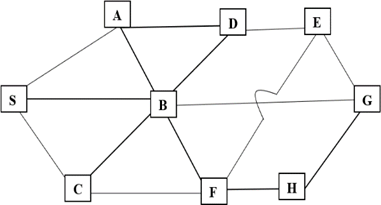

a)	(2 điểm) Hãy viết đoạn code biểu diễn đồ thị trên bằng cách khởi tạo tập đỉnh V và tập cạnh E. (Ví dụ: V = [“S”, “A”, “B”], E =[(“S”, “A”), (“S”, “B”)])

Dán code:

In [4]:
V = ["S", "A", "B", "C", "D", "E", "F", "G", "H"]

E = [
    ("S", "A"),
    ("S", "B"),
    ("S", "C"),
    ("A", "B"),
    ("A", "D"),
    ("B", "C"),
    ("B", "D"),
    ("B", "F"),
    ("B", "G"),
    ("C", "F"),
    ("D", "E"),
    ("E", "F"),
    ("E", "G"),
    ("F", "H"),
    ("G", "H"),
]

class Graph:
    def __init__(self):
        self.adjacency = {}

    def add_node(self, node):
        if node not in self.adjacency:
            self.adjacency[node] = []

    def add_edge(self, u, v):
        self.add_node(u)
        self.add_node(v)
        self.adjacency[u].append(v)
        self.adjacency[v].append(u)


def build_graph(vertices, edges):
    graph = Graph()

    for vertex in vertices:
        graph.add_node(vertex)

    for u, v in edges:
        graph.add_edge(u, v)

    return graph


def main():
    graph = build_graph(V, E)

    print("Tap dinh V:")
    print(V)
    print()
    print("Tap canh E:")
    print(E)
    print()
    print("Danh sach ke:")

    for vertex in V:
        neighbors = ", ".join(graph.adjacency[vertex])
        print(f"{vertex}: {neighbors}")


if __name__ == "__main__":
    main()

Tap dinh V:
['S', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']

Tap canh E:
[('S', 'A'), ('S', 'B'), ('S', 'C'), ('A', 'B'), ('A', 'D'), ('B', 'C'), ('B', 'D'), ('B', 'F'), ('B', 'G'), ('C', 'F'), ('D', 'E'), ('E', 'F'), ('E', 'G'), ('F', 'H'), ('G', 'H')]

Danh sach ke:
S: A, B, C
A: S, B, D
B: S, A, C, D, F, G
C: S, B, F
D: A, B, E
E: D, F, G
F: B, C, E, H
G: B, E, H
H: F, G


### Giải thích câu a

Ở câu a, mục tiêu của em là biểu diễn đồ thị vô hướng theo đúng dạng toán học của nó, tức là dưới dạng $G = (V, E)$.

- `V` là tập đỉnh của đồ thị, tức là toàn bộ các nút xuất hiện trong hình.
- `E` là tập cạnh, tức là các cặp đỉnh có nối với nhau bằng một cạnh trong đồ thị.

Vì đây là đồ thị vô hướng nên mỗi cạnh chỉ cần ghi một lần trong tập `E`, nhưng khi đưa vào cấu trúc dữ liệu của chương trình thì cạnh đó sẽ được hiểu theo cả hai chiều. Nói cách khác, nếu có cạnh giữa hai đỉnh thì từ đỉnh này có thể đi sang đỉnh kia và ngược lại.

Trong phần cài đặt, em chọn cách lưu đồ thị bằng danh sách kề. Cách lưu này phù hợp vì:

- dễ kiểm tra các đỉnh kề với một đỉnh bất kỳ,
- thuận lợi cho các thuật toán tìm kiếm như UCS ở câu b,
- bám sát được cấu trúc của đồ thị trong hình vẽ.

Quy trình em làm ở câu a gồm các bước chính:

1. Khởi tạo tập đỉnh `V` theo đúng các đỉnh xuất hiện trên hình.
2. Khởi tạo tập cạnh `E` theo đúng các liên kết giữa các đỉnh.
3. Tạo một đối tượng đồ thị rỗng.
4. Thêm lần lượt từng đỉnh vào đồ thị.
5. Duyệt qua từng cạnh trong `E` để đưa vào danh sách kề.

Kết quả của câu a là ta thu được một biểu diễn đầy đủ của không gian trạng thái/không gian tìm kiếm của bài toán dưới dạng đồ thị. Từ đó, các câu sau có thể sử dụng trực tiếp cấu trúc này để thực hiện tìm kiếm đường đi.

### Nhận xét về kết quả câu a

Sau khi dựng xong đồ thị, ta kiểm tra lại danh sách đỉnh và danh sách cạnh để chắc chắn rằng đồ thị đã được mô tả đúng như hình.

Danh sách kề là phần quan trọng nhất của biểu diễn này vì nó cho biết từ mỗi đỉnh có thể đi đến những đỉnh nào. Đây chính là dữ liệu mà thuật toán UCS sẽ dùng ở câu b để mở rộng trạng thái theo chiều sâu.

Nếu danh sách kề khớp với hình vẽ thì có thể xem phần biểu diễn đồ thị ở câu a là hoàn thành chính xác.

b)	(3 điểm) Hãy viết chương trình sử dụng thuật toán tìm kiếm chi phí cực tiểu (UCS) để tìm đường đi từ đỉnh “S” đến đỉnh “G” trong đồ thị được biểu diễn ở câu a). Trong chương trình, hãy in ra thứ tự đỉnh khám phá trong quá trình tìm kiếm. Nếu không tìm thấy thì in “Khong tim thay duong di”

Dán code:

In [6]:
import heapq


V = ["S", "A", "B", "C", "D", "E", "F", "G", "H"]

E = [
    ("S", "A"),
    ("S", "B"),
    ("S", "C"),
    ("A", "B"),
    ("A", "D"),
    ("B", "C"),
    ("B", "D"),
    ("B", "F"),
    ("B", "G"),
    ("C", "F"),
    ("D", "E"),
    ("E", "F"),
    ("E", "G"),
    ("F", "H"),
    ("G", "H"),
]


class Graph:
    def __init__(self):
        self.adjacency = {}

    def add_node(self, node):
        if node not in self.adjacency:
            self.adjacency[node] = []

    def add_edge(self, u, v, cost=1):
        self.add_node(u)
        self.add_node(v)
        self.adjacency[u].append((v, cost))
        self.adjacency[v].append((u, cost))

    def sort_neighbors(self, vertex_order):
        for vertex in self.adjacency:
            self.adjacency[vertex].sort(key=lambda item: vertex_order[item[0]])


def build_graph(vertices, edges):
    graph = Graph()

    for vertex in vertices:
        graph.add_node(vertex)

    for u, v in edges:
        graph.add_edge(u, v)

    vertex_order = {vertex: index for index, vertex in enumerate(vertices)}
    graph.sort_neighbors(vertex_order)
    return graph


def reconstruct_path(parent, start, goal):
    path = []
    current = goal

    while current is not None:
        path.append(current)
        current = parent[current]

    path.reverse()
    return path if path[0] == start else None


def format_adjacency(adjacency):
    lines = []

    for vertex in V:
        neighbors = ", ".join(f"{neighbor}({cost})" for neighbor, cost in adjacency[vertex])
        lines.append(f"{vertex}: {neighbors}")

    return "\n".join(lines)


def format_frontier(frontier):
    if not frontier:
        return "[]"

    ordered_items = sorted(frontier)
    parts = []

    for cost, _, node in ordered_items:
        parts.append(f"{node}(cost={cost})")

    return "[" + ", ".join(parts) + "]"


def format_parent_map(parent):
    items = []

    for vertex in V:
        if vertex in parent:
            previous = parent[vertex]
            previous_text = "None" if previous is None else previous
            items.append(f"{vertex}:{previous_text}")

    return "{" + ", ".join(items) + "}"


def format_ucs_steps(steps):
    if not steps:
        return "Khong co buoc UCS nao duoc ghi nhan."

    headers = ["Step", "Popped", "Cost", "Frontier", "Updated", "Parents"]
    rows = []

    for step in steps:
        updated_text = ", ".join(step["updated"]) if step["updated"] else "-"
        rows.append([
            str(step["step"]),
            step["popped"],
            str(step["cost"]),
            step["frontier"],
            updated_text,
            format_parent_map(step["parents"]),
        ])

    widths = [len(header) for header in headers]

    for row in rows:
        for index, value in enumerate(row):
            widths[index] = max(widths[index], len(value))

    lines = []
    lines.append(" | ".join(headers[index].ljust(widths[index]) for index in range(len(headers))))
    lines.append("-+-".join("-" * width for width in widths))

    for row in rows:
        lines.append(" | ".join(row[index].ljust(widths[index]) for index in range(len(row))))

    return "\n".join(lines)


def ucs(adjacency, start, goal):
    frontier = []
    order = 0
    heapq.heappush(frontier, (0, order, start))

    parent = {start: None}
    cost_so_far = {start: 0}
    visited = set()
    exploration_order = []
    steps = []
    step_no = 0

    while frontier:
        current_cost, _, current = heapq.heappop(frontier)

        if current in visited:
            continue

        visited.add(current)
        exploration_order.append(current)
        updated = []

        if current == goal:
            step_no += 1
            steps.append({
                "step": step_no,
                "popped": current,
                "cost": current_cost,
                "frontier": format_frontier(frontier),
                "updated": updated,
                "parents": dict(parent),
            })
            return reconstruct_path(parent, start, goal), exploration_order, steps

        for neighbor, edge_cost in adjacency[current]:
            new_cost = current_cost + edge_cost

            if neighbor not in cost_so_far or new_cost < cost_so_far[neighbor]:
                cost_so_far[neighbor] = new_cost
                parent[neighbor] = current
                order += 1
                heapq.heappush(frontier, (new_cost, order, neighbor))
                updated.append(f"{neighbor}(cost={new_cost})")

        step_no += 1
        steps.append({
            "step": step_no,
            "popped": current,
            "cost": current_cost,
            "frontier": format_frontier(frontier),
            "updated": updated,
            "parents": dict(parent),
        })

    return None, exploration_order, steps


def solve():
    graph = build_graph(V, E)
    path, exploration_order, steps = ucs(graph.adjacency, "S", "G")

    lines = [
        "THUAT TOAN UCS",
        "",
        "Tap dinh V:",
        str(V),
        "",
        "Tap canh E:",
        str(E),
        "",
        "Danh sach ke kem chi phi:",
        format_adjacency(graph.adjacency),
        "",
        "Bang cac buoc UCS:",
        format_ucs_steps(steps),
        "",
        "Thu tu dinh kham pha:",
        " -> ".join(exploration_order),
        "",
    ]

    if path is None:
        lines.append("Khong tim thay duong di")
    else:
        lines.append("Duong di tu S den G:")
        lines.append(" -> ".join(path))

    return "\n".join(lines)


def main():
    print(solve())


if __name__ == "__main__":
    main()


THUAT TOAN UCS

Tap dinh V:
['S', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']

Tap canh E:
[('S', 'A'), ('S', 'B'), ('S', 'C'), ('A', 'B'), ('A', 'D'), ('B', 'C'), ('B', 'D'), ('B', 'F'), ('B', 'G'), ('C', 'F'), ('D', 'E'), ('E', 'F'), ('E', 'G'), ('F', 'H'), ('G', 'H')]

Danh sach ke kem chi phi:
S: A(1), B(1), C(1)
A: S(1), B(1), D(1)
B: S(1), A(1), C(1), D(1), F(1), G(1)
C: S(1), B(1), F(1)
D: A(1), B(1), E(1)
E: D(1), F(1), G(1)
F: B(1), C(1), E(1), H(1)
G: B(1), E(1), H(1)
H: F(1), G(1)

Bang cac buoc UCS:
Step | Popped | Cost | Frontier                                     | Updated                         | Parents                                         
-----+--------+------+----------------------------------------------+---------------------------------+-------------------------------------------------
1    | S      | 0    | [A(cost=1), B(cost=1), C(cost=1)]            | A(cost=1), B(cost=1), C(cost=1) | {S:None, A:S, B:S, C:S}                         
2    | A      | 1    | [B(co

### Giải thích tác dụng của từng hàm

- `Graph.__init__()`: khởi tạo đồ thị rỗng bằng biến `adjacency`.
- `Graph.add_node(node)`: thêm một đỉnh vào đồ thị nếu đỉnh đó chưa tồn tại.
- `Graph.add_edge(u, v, cost=1)`: thêm cạnh vô hướng giữa `u` và `v` kèm chi phí. Trong bài này chi phí mặc định của mỗi cạnh là `1`.
- `Graph.sort_neighbors(vertex_order)`: sắp xếp danh sách kề theo thứ tự tập đỉnh `V`, giúp quá trình duyệt có kết quả ổn định.
- `build_graph(vertices, edges)`: tạo đồ thị từ tập đỉnh và tập cạnh, thêm toàn bộ cạnh vào đồ thị, sắp xếp danh sách kề rồi trả về đồ thị hoàn chỉnh.
- `reconstruct_path(parent, start, goal)`: truy vết đường đi từ `goal` về `start` dựa trên dictionary `parent`, sau đó đảo ngược để lấy đường đi đúng chiều.
- `format_adjacency(adjacency)`: chuyển danh sách kề có kèm chi phí thành chuỗi nhiều dòng để in ra dễ đọc.
- `format_frontier(frontier)`: định dạng hàng đợi ưu tiên của UCS, hiển thị các đỉnh đang chờ xét cùng tổng chi phí hiện tại.
- `format_parent_map(parent)`: chuyển thông tin cha của các đỉnh thành chuỗi để đưa vào bảng bước chạy.
- `format_ucs_steps(steps)`: tạo bảng văn bản mô tả từng bước UCS, gồm đỉnh vừa lấy ra, chi phí hiện tại, frontier, các đỉnh được cập nhật và quan hệ cha.
- `ucs(adjacency, start, goal)`: thực hiện thuật toán Uniform Cost Search bằng priority queue. Hàm luôn lấy đỉnh có tổng chi phí nhỏ nhất ra trước, cập nhật chi phí tốt hơn cho các đỉnh kề, lưu `parent` và trả về đường đi khi gặp `goal`.
- `solve()`: gom dữ liệu đầu vào, kết quả chạy UCS, bảng bước chạy, thứ tự khám phá và đường đi thành một chuỗi kết quả hoàn chỉnh.
- `main()`: gọi `solve()` và in kết quả ra màn hình.

### Giải thích câu b

Ở câu b, em sử dụng thuật toán UCS để tìm đường đi từ đỉnh `S` đến đỉnh `G` trên đồ thị đã biểu diễn ở câu a.

UCS hoạt động theo nguyên tắc luôn mở rộng đỉnh có tổng chi phí từ đỉnh xuất phát nhỏ nhất. Với bài này, mỗi cạnh được xem có chi phí bằng `1`, nên UCS sẽ mở rộng các đỉnh theo chi phí tăng dần.

### Công thức / nguyên tắc sử dụng

Khi đi từ đỉnh `u` sang đỉnh kề `v`, chi phí mới được tính như sau:

```text
cost(v) = cost(u) + w(u, v)
```

Trong bài này, mỗi cạnh có chi phí `w(u, v) = 1`. Vì vậy UCS sẽ mở rộng các đỉnh theo thứ tự chi phí tăng dần và tìm được đường đi có tổng chi phí nhỏ nhất.

Trong quá trình cài đặt, em sử dụng các thành phần sau:

- một hàng đợi ưu tiên để lưu các đỉnh chờ khám phá,
- một bảng `cost_so_far` để lưu chi phí nhỏ nhất đã biết tới từng đỉnh,
- một cấu trúc `parent` để truy vết lại đường đi,
- một tập `visited` để tránh xử lý lại đỉnh đã chọn,
- một bảng ghi lại từng bước xử lý của UCS.

Ở mỗi bước, thuật toán lấy đỉnh có chi phí nhỏ nhất ra khỏi hàng đợi ưu tiên. Sau đó, thuật toán xét các đỉnh kề và cập nhật lại chi phí nếu tìm được đường đi rẻ hơn.

Bảng các bước UCS giúp theo dõi rõ đỉnh nào được lấy ra, chi phí hiện tại, trạng thái hàng đợi ưu tiên, các đỉnh được cập nhật và thông tin đỉnh cha sau mỗi bước.

Nếu tìm thấy `G`, thuật toán dừng lại và truy vết theo `parent` để dựng đường đi. Nếu hàng đợi ưu tiên rỗng mà chưa gặp `G`, chương trình kết luận không tìm thấy đường đi.


### Nhận xét về kết quả câu b

Kết quả cuối cùng cho thấy thuật toán UCS đã tìm được đường đi từ `S` đến `G` là `S -> B -> G`.

Đây là một đường đi hợp lệ trong đồ thị vì:

- từ `S` có thể đi đến `B`,
- từ `B` có thể đi đến `G`.

Thứ tự đỉnh khám phá là `S -> A -> B -> C -> D -> F -> G`. Do các cạnh đều có chi phí bằng `1`, UCS mở rộng các đỉnh theo mức chi phí tăng dần. Khi đến `G`, thuật toán truy vết theo `parent` và thu được đường đi `S -> B -> G`.


Dán kết quả thực thi:

```text
THUAT TOAN UCS

Tap dinh V:
['S', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']

Tap canh E:
[('S', 'A'), ('S', 'B'), ('S', 'C'), ('A', 'B'), ('A', 'D'), ('B', 'C'), ('B', 'D'), ('B', 'F'), ('B', 'G'), ('C', 'F'), ('D', 'E'), ('E', 'F'), ('E', 'G'), ('F', 'H'), ('G', 'H')]

Danh sach ke kem chi phi:
S: A(1), B(1), C(1)
A: S(1), B(1), D(1)
B: S(1), A(1), C(1), D(1), F(1), G(1)
C: S(1), B(1), F(1)
D: A(1), B(1), E(1)
E: D(1), F(1), G(1)
F: B(1), C(1), E(1), H(1)
G: B(1), E(1), H(1)
H: F(1), G(1)

Bang cac buoc UCS:
Step | Popped | Cost | Frontier                                     | Updated                         | Parents                                         
-----+--------+------+----------------------------------------------+---------------------------------+-------------------------------------------------
1    | S      | 0    | [A(cost=1), B(cost=1), C(cost=1)]            | A(cost=1), B(cost=1), C(cost=1) | {S:None, A:S, B:S, C:S}                         
2    | A      | 1    | [B(cost=1), C(cost=1), D(cost=2)]            | D(cost=2)                       | {S:None, A:S, B:S, C:S, D:A}                    
3    | B      | 1    | [C(cost=1), D(cost=2), F(cost=2), G(cost=2)] | F(cost=2), G(cost=2)            | {S:None, A:S, B:S, C:S, D:A, F:B, G:B}          
4    | C      | 1    | [D(cost=2), F(cost=2), G(cost=2)]            | -                               | {S:None, A:S, B:S, C:S, D:A, F:B, G:B}          
5    | D      | 2    | [F(cost=2), G(cost=2), E(cost=3)]            | E(cost=3)                       | {S:None, A:S, B:S, C:S, D:A, E:D, F:B, G:B}     
6    | F      | 2    | [G(cost=2), E(cost=3), H(cost=3)]            | H(cost=3)                       | {S:None, A:S, B:S, C:S, D:A, E:D, F:B, G:B, H:F}
7    | G      | 2    | [E(cost=3), H(cost=3)]                       | -                               | {S:None, A:S, B:S, C:S, D:A, E:D, F:B, G:B, H:F}

Thu tu dinh kham pha:
S -> A -> B -> C -> D -> F -> G

Duong di tu S den G:
S -> B -> G
```